# EDA — Walmart Store Sales Forecasting

Joint notebook (both teammates). Findings feed the README:
- 3331 (Store, Dept) series, 143 weeks, 39-week test horizon
- holiday weeks weigh 5x in WMAE
- MarkDowns only exist after Nov 2011 (but fully present in test period)
- CPI/Unemployment missing in the test tail
- 1285 negative-sales rows (returns), 11 cold-start test series

In [12]:
!pip install -q mlflow
!git clone https://github.com/ekatsirekidze/walmart-sales-forecasting.git
import sys; sys.path.insert(0, "/kaggle/working/walmart-sales-forecasting")

import glob, os, shutil, zipfile
os.makedirs("data", exist_ok=True)
for f in glob.glob("/kaggle/input/walmart-recruiting-store-sales-forecasting/*"):
    (zipfile.ZipFile(f).extractall("data") if f.endswith(".zip") else shutil.copy(f, "data"))

fatal: destination path 'walmart-sales-forecasting' already exists and is not an empty directory.


In [13]:
import glob, os, shutil, zipfile

src = glob.glob("/kaggle/input/*walmart*") + glob.glob("/kaggle/input/*/*walmart*")
assert src, "still not found"
print("using:", src[0])

os.makedirs("data", exist_ok=True)
for f in glob.glob(src[0] + "/*"):
    (zipfile.ZipFile(f).extractall("data") if f.endswith(".zip") else shutil.copy(f, "data"))

print("data/:", os.listdir("data"))

using: /kaggle/input/competitions/walmart-recruiting-store-sales-forecasting
data/: ['train.csv', 'sampleSubmission.csv', 'test.csv', 'features.csv', 'stores.csv']


In [14]:
import sys
sys.path.insert(0, "/kaggle/working/walmart-sales-forecasting")

import numpy as np
import pandas as pd
import mlflow
import matplotlib.pyplot as plt

from src.data import load_raw
from src.metrics import wmae_report
from src.validation import FOLDS, split_fold
from src.mlflow_utils import setup_mlflow

train, test, features, stores = load_raw("data")
print(train.shape, test.shape)

(421570, 5) (115064, 4)


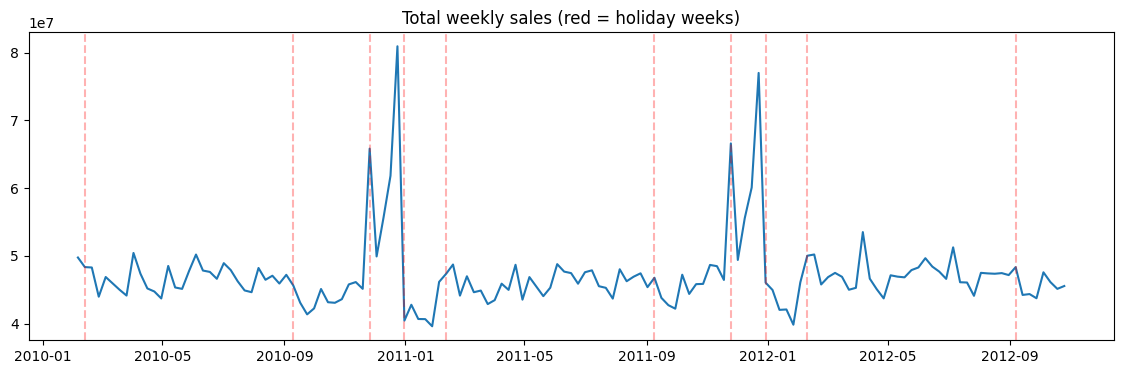

In [15]:
# Total weekly sales with holiday markers — the two December spikes rule this dataset
tot = train.groupby("Date")["Weekly_Sales"].sum()
hol = train.loc[train.IsHoliday, "Date"].unique()
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(tot.index, tot.values)
for h in hol:
    ax.axvline(h, color="red", alpha=0.3, ls="--")
ax.set_title("Total weekly sales (red = holiday weeks)")
plt.show()

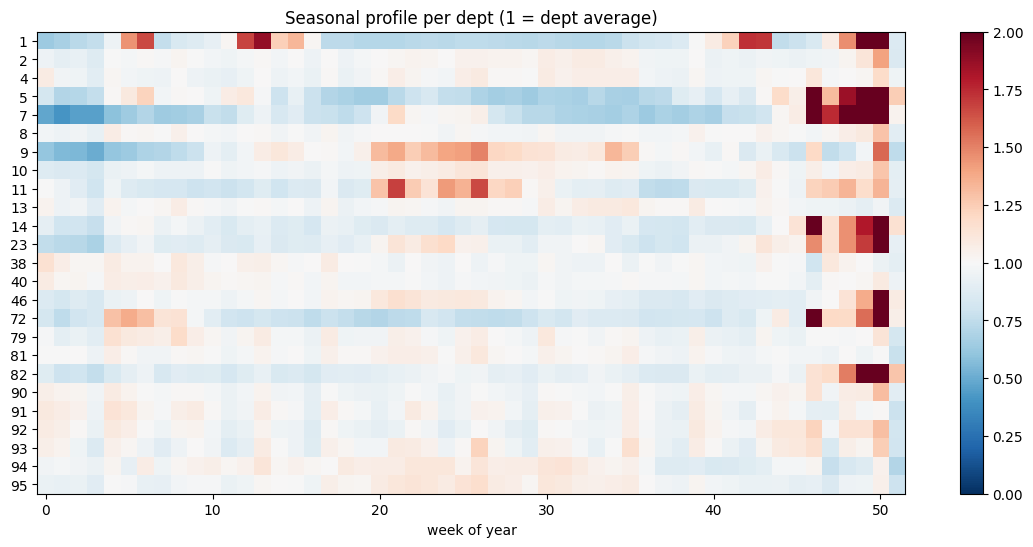

In [16]:
# Seasonality: dept x week-of-year heatmap (top-25 depts by volume)
t = train.assign(woy=train.Date.dt.isocalendar().week.astype(int))
top = t.groupby("Dept").Weekly_Sales.sum().nlargest(25).index
pv = t[t.Dept.isin(top)].pivot_table(index="Dept", columns="woy", values="Weekly_Sales", aggfunc="mean")
pv = pv.div(pv.mean(axis=1), axis=0)  # normalize per dept
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pv, aspect="auto", cmap="RdBu_r", vmin=0, vmax=2)
ax.set_yticks(range(len(pv))); ax.set_yticklabels(pv.index)
ax.set_xlabel("week of year"); ax.set_title("Seasonal profile per dept (1 = dept average)")
fig.colorbar(im); plt.show()

In [17]:
# Store types, series lengths, negatives
print(stores.groupby("Type").agg(n=("Store", "count"), avg_size=("Size", "mean")))
lens = train.groupby(["Store", "Dept"]).size()
print("\nseries length distribution:\n", lens.describe())
print("\nnegative sales rows:", (train.Weekly_Sales < 0).sum())
tr_series = set(train.groupby(["Store", "Dept"]).groups)
te_series = set(test.groupby(["Store", "Dept"]).groups)
print("cold-start test series (no train history):", len(te_series - tr_series))

       n       avg_size
Type                   
A     22  177247.727273
B     17  101190.705882
C      6   40541.666667

series length distribution:
 count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
dtype: float64

negative sales rows: 1285
cold-start test series (no train history): 11


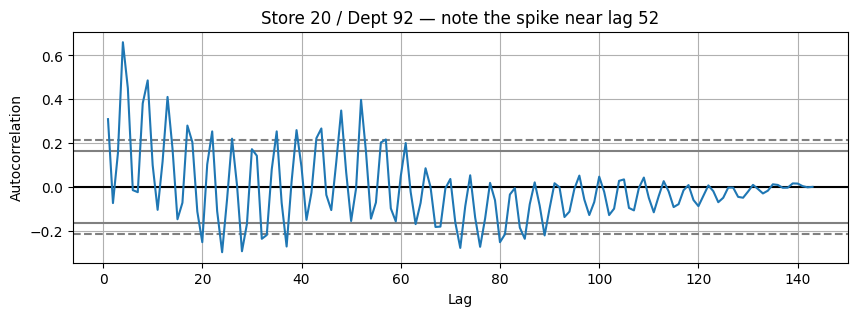

In [18]:
# Autocorrelation of a large series -> the lag-52 peak that motivates everything
from pandas.plotting import autocorrelation_plot
s = train[(train.Store == 20) & (train.Dept == 92)].set_index("Date").Weekly_Sales
fig, ax = plt.subplots(figsize=(10, 3))
autocorrelation_plot(s, ax=ax)
ax.set_title("Store 20 / Dept 92 — note the spike near lag 52")
plt.show()

<Axes: title={'center': 'Share of stores reporting each MarkDown'}, xlabel='Date'>

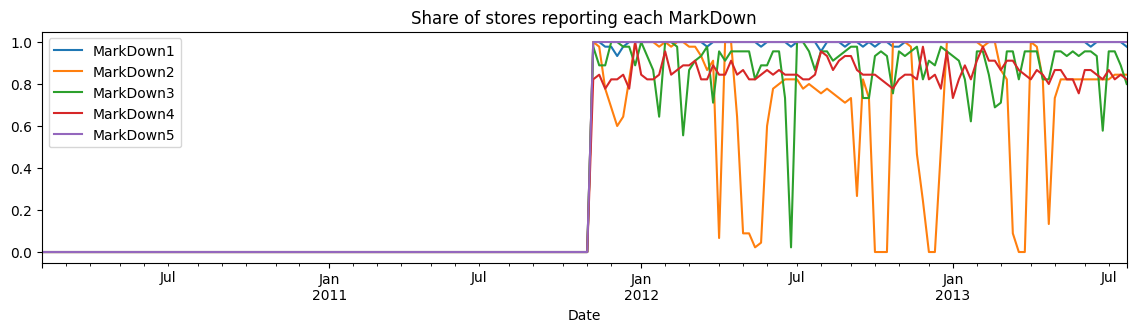

In [19]:
# Markdown availability over time (why NA -> 0 + presence flag)
f = features.set_index("Date")[[f"MarkDown{i}" for i in range(1, 6)]]
f.notna().groupby(level=0).mean().plot(figsize=(14, 3), title="Share of stores reporting each MarkDown")

## EDA findings

1. **Two December spikes dominate** — total sales jump ~60-80% in the weeks
   before Thanksgiving and Christmas. These weeks weigh 5x in the metric, so
   models win or lose here. Note the spike is the week *before* the holiday;
   the holiday week itself (e.g. after Christmas) actually dips.
2. **Strong yearly seasonality** — the autocorrelation of a large series peaks
   near lag 52. "Same week last year" is a powerful predictor → lag-52 features
   and a seasonal-naive baseline.
3. **Dept-specific seasonal profiles** — the heatmap shows depts 1/7/14/72/82
   explode in weeks 46-51 while others are flat → a global model needs Dept
   interactions (or per-series information), one shared curve won't fit all.
4. **MarkDowns exist only from Nov 2011** and are fully present in the test
   period → NA means "no promotion", so we fill 0 + add a presence flag.
5. **Uneven history**: 3331 series, median length 143 weeks but some have 1
   week; 11 test series have no history at all → global model + fallbacks,
   not one model per series.
6. **1285 negative sales rows** (returns) — kept as-is; the metric is plain
   MAE on raw dollars.
